In [1]:
# ============================================================
# VESSEL INTELLIGENCE MODEL
# ============================================================
# Purpose:
#   Leakage-safe waiting-time prediction + vessel feasibility +
#   vessel suitability scoring + Top-N vessel ranking.
#
# Input:
#   vessel_intelligence_daily.csv
#
# First supervised target:
#   avg_waiting_hours
#
# Model:
#   Median baseline
#   Random Forest
#   XGBoost (if installed)
#
# IMPORTANT:
#   - Prototype suitability/eligibility labels are NOT used as
#     ML ground truth.
#   - Future fields are excluded from model inputs.
#   - Hard-feasibility checks are recomputed at prediction time.
#   - Loading-port feasibility is UNKNOWN when the dataset
#     contains only an origin country and no loading-port ID.
# ============================================================

In [2]:

# ============================================================
# 1. OPTIONAL INSTALLATION
# ============================================================

# Run only if required packages are unavailable.
#
# %pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib shap

In [3]:
# ============================================================
# 2. IMPORTS
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# Optional XGBoost
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False


# Optional SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False


print("=" * 80)
print("VESSEL INTELLIGENCE MODEL")
print("=" * 80)
print("XGBoost available:", XGB_AVAILABLE)
print("SHAP available:", SHAP_AVAILABLE)


VESSEL INTELLIGENCE MODEL
XGBoost available: True
SHAP available: True


In [4]:
# ============================================================
# 3. PATH CONFIGURATION
# ============================================================

ROOT = Path.cwd()

candidate_paths = [
    ROOT / "vessel_intelligence_daily.csv",
    ROOT / "vessel_intelligence_data" / "vessel_intelligence_daily.csv",
    Path("/mnt/data/vessel_intelligence_daily.csv"),
]

DATA_PATH = None

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "vessel_intelligence_daily.csv was not found.\n"
        "Place it in the notebook folder or vessel_intelligence_data/."
    )

ARTIFACT_DIR = ROOT / "vessel_intelligence_artifacts"
PLOT_DIR = ARTIFACT_DIR / "plots"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH.resolve())
print("Artifacts:", ARTIFACT_DIR.resolve())


Dataset: C:\Users\samag\OneDrive\Desktop\Hackathon\SIH2026\LSTM_model\vessel_intelligence\vessel_intelligence_data\vessel_intelligence_daily.csv
Artifacts: C:\Users\samag\OneDrive\Desktop\Hackathon\SIH2026\LSTM_model\vessel_intelligence\vessel_intelligence_artifacts


In [5]:
# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

if "date" not in df.columns:
    raise ValueError("Required column 'date' is missing.")

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df = df.dropna(
    subset=["date"]
).sort_values(
    "date"
).reset_index(drop=True)


# Normalize text columns
TEXT_COLUMNS = [
    "vessel_name",
    "vessel_class",
    "origin",
    "destination_port",
    "cargo_type",
]

for col in TEXT_COLUMNS:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
        )


print("\nDataset shape:", df.shape)

print(
    "Date range:",
    df["date"].min().date(),
    "→",
    df["date"].max().date()
)

print(
    "Unique dates:",
    df["date"].nunique()
)

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

if "vessel_class" in df.columns:
    print("\nVessel classes:")
    print(
        df["vessel_class"]
        .value_counts(dropna=False)
    )

if "destination_port" in df.columns:
    print("\nDestination ports:")
    print(
        sorted(
            df["destination_port"]
            .dropna()
            .unique()
            .tolist()
        )
    )


Dataset shape: (441048, 74)
Date range: 2020-01-01 → 2025-12-01
Unique dates: 2162
Duplicate rows: 0

Vessel classes:
vessel_class
Panamax     311328
Capesize    129720
Name: count, dtype: Int64

Destination ports:
['Dhamra', 'Gangavaram', 'Gopalpur', 'Haldia', 'Paradip', 'Vizag']


In [6]:
# ============================================================
# 5. DATA QUALITY PROFILE
# ============================================================

profile = pd.DataFrame({
    "dtype":
        df.dtypes.astype(str),

    "missing":
        df.isna().sum(),

    "missing_pct":
        df.isna().mean() * 100,

    "nunique":
        df.nunique()
}).sort_values(
    "missing_pct",
    ascending=False
)

display(profile.head(40))

profile.to_csv(
    ARTIFACT_DIR / "data_quality_profile.csv"
)


,dtype,missing,missing_pct,nunique
ais_avg_draft_m,float64,409962,92.951788,162
ais_low_speed_pct,float64,409962,92.951788,10
ais_avg_speed_knots,float64,409962,92.951788,326
avg_port_stay_hours,float64,405450,91.928770,332
weather_storm_flag,float64,378828,85.892692,2
weather_wave_period,float64,378828,85.892692,61
weather_wave_height,float64,378828,85.892692,314
weather_cyclone_flag,float64,378828,85.892692,2
weather_wind_speed,float64,378828,85.892692,345
berth_count,float64,294032,66.666667,1


In [7]:

# ============================================================
# 6. REQUIRED TARGET
# ============================================================

TARGET = "avg_waiting_hours"

if TARGET not in df.columns:
    raise ValueError(
        f"'{TARGET}' is not present in vessel_intelligence_daily.csv."
    )

df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="coerce"
)

df = df.dropna(
    subset=[TARGET]
).copy()

In [8]:
# ============================================================
# 7. LEAKAGE POLICY
# ============================================================
# These fields must NOT be used as ML inputs.
#
# The suitability/eligibility fields in the source file are
# derived prototype outputs, not independent ground truth.
#
# Historical average/median waiting may also encode the target
# directly, so they are excluded from the raw feature set.
# ============================================================

LEAKAGE_COLUMNS = {
    # Target
    TARGET,

    # Future variables
    "future_freight_usd_mt_7d",
    "future_freight_usd_mt_14d",
    "future_freight_usd_mt_30d",
    "future_freight_usd_mt_60d",

    "future_freight_return_7d_pct",
    "future_freight_return_14d_pct",
    "future_freight_return_30d_pct",
    "future_freight_return_60d_pct",

    # Prototype outputs
    "vessel_suitability_score",
    "eligibility",
    "recommendation_tier",

    # Directly target-derived / prototype-derived fields
    "historical_avg_wait_hours",
    "historical_median_wait_hours",
    "operational_risk_score",
    "economic_score",
    "port_compatibility_score",
    "cargo_fit_score",
    "cargo_utilization_pct",

    "reference_cargo_mt",

    "dwt_margin_mt",
    "loa_margin_m",
    "beam_margin_m",
    "draft_margin_m",
    "berth_loa_margin_m",

    "dwt_feasible",
    "loa_feasible",
    "beam_feasible",
    "draft_feasible",
    "berth_feasible",
    "port_feasible",
    "cargo_capacity_fit",

    # Quality/source metadata
    "data_quality_missing_pct",
    "source_note",
}

# Never use row identity columns directly.
ID_COLUMNS = {
    "date",
    "imo",
    "vessel_name",
}

In [9]:

# ============================================================
# 8. BACKWARD-LOOKING FEATURE ENGINEERING
# ============================================================

work = df.copy()

work = work.sort_values(
    ["date"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Calendar features
# ------------------------------------------------------------

work["year"] = work["date"].dt.year
work["month"] = work["date"].dt.month
work["quarter"] = work["date"].dt.quarter
work["day_of_week"] = work["date"].dt.dayofweek
work["day_of_year"] = work["date"].dt.dayofyear

work["month_sin"] = np.sin(
    2 * np.pi * work["month"] / 12
)

work["month_cos"] = np.cos(
    2 * np.pi * work["month"] / 12
)

work["day_of_year_sin"] = np.sin(
    2 * np.pi * work["day_of_year"] / 365.25
)

work["day_of_year_cos"] = np.cos(
    2 * np.pi * work["day_of_year"] / 365.25
)


# ------------------------------------------------------------
# Group for backward-looking operational history
# ------------------------------------------------------------

if "imo" in work.columns:
    HISTORY_GROUP = "imo"
elif "destination_port" in work.columns:
    HISTORY_GROUP = "destination_port"
else:
    HISTORY_GROUP = None


# ------------------------------------------------------------
# Safe lag/rolling features
# ------------------------------------------------------------

ROLLING_COLUMNS = [
    "avg_waiting_hours",
    "port_calls_count",
    "ais_low_speed_pct",
    "historical_queue_length",
    "freight_usd_mt",
    "bunker_price_usd_mt",
]

ROLLING_COLUMNS = [
    c for c in ROLLING_COLUMNS
    if c in work.columns
]

if HISTORY_GROUP is not None:

    work = work.sort_values(
        [HISTORY_GROUP, "date"]
    ).reset_index(drop=True)

    for col in ROLLING_COLUMNS:

        # Previous observation only
        work[f"{col}_lag1"] = (
            work.groupby(HISTORY_GROUP)[col]
            .shift(1)
        )

        # Previous 7 observations only
        work[f"{col}_rolling7"] = (
            work.groupby(HISTORY_GROUP)[col]
            .transform(
                lambda s:
                s.shift(1)
                .rolling(
                    7,
                    min_periods=2
                )
                .mean()
            )
        )

        # Previous 30 observations only
        work[f"{col}_rolling30"] = (
            work.groupby(HISTORY_GROUP)[col]
            .transform(
                lambda s:
                s.shift(1)
                .rolling(
                    30,
                    min_periods=3
                )
                .mean()
            )
        )

    work = work.sort_values(
        "date"
    ).reset_index(drop=True)

In [10]:
# ============================================================
# 9. REMOVE LOW-INFORMATION FEATURES
# ============================================================

MODEL_FEATURES = [
    c for c in work.columns
    if c not in LEAKAGE_COLUMNS
    and c not in ID_COLUMNS
]

# Remove source metadata and obviously non-model identifiers.
REMOVE_ALWAYS = {
    "source_type",
    "source",
}

MODEL_FEATURES = [
    c for c in MODEL_FEATURES
    if c not in REMOVE_ALWAYS
]


# Remove constant fields
constant_features = []

for col in MODEL_FEATURES:
    if work[col].nunique(dropna=True) <= 1:
        constant_features.append(col)

MODEL_FEATURES = [
    c for c in MODEL_FEATURES
    if c not in constant_features
]

print("\nFeature count:", len(MODEL_FEATURES))

if constant_features:
    print(
        "Dropped constant features:",
        constant_features
    )



Feature count: 68
Dropped constant features: ['crane_count', 'crane_capacity_mt', 'berth_count', 'has_tidal_restriction']


In [11]:
# ============================================================
# 10. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

unique_dates = (
    work["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

n_dates = len(unique_dates)

if n_dates < 30:
    raise ValueError(
        "Not enough unique dates for chronological model validation."
    )

train_cut = int(n_dates * 0.70)
valid_cut = int(n_dates * 0.85)

TRAIN_END = unique_dates.iloc[
    train_cut - 1
]

VALIDATION_END = unique_dates.iloc[
    valid_cut - 1
]

train_df = work[
    work["date"] <= TRAIN_END
].copy()

validation_df = work[
    (work["date"] > TRAIN_END)
    &
    (work["date"] <= VALIDATION_END)
].copy()

test_df = work[
    work["date"] > VALIDATION_END
].copy()


print("\n" + "=" * 80)
print("TIME-BASED SPLIT")
print("=" * 80)

print(
    "TRAIN:",
    train_df["date"].min().date(),
    "→",
    train_df["date"].max().date(),
    "| rows:",
    len(train_df)
)

print(
    "VALID:",
    validation_df["date"].min().date(),
    "→",
    validation_df["date"].max().date(),
    "| rows:",
    len(validation_df)
)

print(
    "TEST :",
    test_df["date"].min().date(),
    "→",
    test_df["date"].max().date(),
    "| rows:",
    len(test_df)
)


TIME-BASED SPLIT
TRAIN: 2020-01-01 → 2024-02-21 | rows: 308652
VALID: 2024-02-22 → 2025-01-10 | rows: 66096
TEST : 2025-01-11 → 2025-12-01 | rows: 66300


In [12]:
# ============================================================
# 11. PREPARE X / y
# ============================================================

X_train = train_df[
    MODEL_FEATURES
].copy()

y_train = train_df[
    TARGET
].astype(float)

X_valid = validation_df[
    MODEL_FEATURES
].copy()

y_valid = validation_df[
    TARGET
].astype(float)

X_test = test_df[
    MODEL_FEATURES
].copy()

y_test = test_df[
    TARGET
].astype(float)


In [13]:
# ============================================================
# 12. CATEGORICAL + NUMERIC COLUMNS
# ============================================================

categorical_columns = (
    X_train
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

numeric_columns = (
    X_train
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

print("\nNumeric features:", len(numeric_columns))
print("Categorical features:", len(categorical_columns))



Numeric features: 63
Categorical features: 5


In [14]:

# ============================================================
# 13. PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numeric_columns
        ),

        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_columns
        )
    ],
    remainder="drop"
)


In [15]:

# ============================================================
# 14. MODELS
# ============================================================

models = {

    "baseline_median":
        DummyRegressor(
            strategy="median"
        ),

    "random_forest":
        RandomForestRegressor(
            n_estimators=400,
            max_depth=16,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        )
}

if XGB_AVAILABLE:

    models["xgboost"] = XGBRegressor(

        n_estimators=600,

        max_depth=5,

        learning_rate=0.04,

        subsample=0.85,

        colsample_bytree=0.85,

        min_child_weight=3,

        reg_alpha=0.05,

        reg_lambda=1.0,

        objective="reg:squarederror",

        random_state=42,

        n_jobs=2
    )


In [16]:

# ============================================================
# 15. TRAIN + VALIDATE
# ============================================================

validation_results = []
fitted_models = {}

for model_name, estimator in models.items():

    print("\nTraining:", model_name)

    pipeline = Pipeline([
        (
            "preprocess",
            preprocessor
        ),
        (
            "model",
            estimator
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    pred_valid = np.clip(
        pipeline.predict(X_valid),
        0,
        None
    )

    mae = mean_absolute_error(
        y_valid,
        pred_valid
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            pred_valid
        )
    )

    r2 = r2_score(
        y_valid,
        pred_valid
    )

    validation_results.append({
        "model":
            model_name,

        "validation_MAE":
            mae,

        "validation_RMSE":
            rmse,

        "validation_R2":
            r2
    })

    fitted_models[
        model_name
    ] = pipeline


validation_results_df = (
    pd.DataFrame(
        validation_results
    )
    .sort_values(
        ["validation_MAE", "validation_RMSE"]
    )
    .reset_index(drop=True)
)

display(
    validation_results_df
)

validation_results_df.to_csv(
    ARTIFACT_DIR /
    "validation_results.csv",
    index=False
)



Training: baseline_median

Training: random_forest

Training: xgboost


,model,validation_MAE,validation_RMSE,validation_R2
0,xgboost,1.063445,4.021044,0.964854
1,random_forest,1.072416,4.826226,0.949370
2,baseline_median,16.431368,23.199460,-0.169908


In [17]:
# ============================================================
# 16. SELECT BEST MODEL USING VALIDATION ONLY
# ============================================================

BEST_MODEL_NAME = (
    validation_results_df
    .iloc[0]["model"]
)

BEST_MODEL = fitted_models[
    BEST_MODEL_NAME
]

print(
    "\nSelected model using validation:",
    BEST_MODEL_NAME
)



Selected model using validation: xgboost


In [18]:
# ============================================================
# 17. FINAL UNBIASED TEST EVALUATION
# ============================================================

test_prediction = np.clip(
    BEST_MODEL.predict(X_test),
    0,
    None
)

test_mae = mean_absolute_error(
    y_test,
    test_prediction
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_prediction
    )
)

test_r2 = r2_score(
    y_test,
    test_prediction
)

final_test_metrics = pd.DataFrame([{
    "model":
        BEST_MODEL_NAME,

    "test_MAE_hours":
        test_mae,

    "test_RMSE_hours":
        test_rmse,

    "test_R2":
        test_r2
}])

print("\n" + "=" * 80)
print("FINAL TEST PERFORMANCE")
print("=" * 80)

display(
    final_test_metrics
)

final_test_metrics.to_csv(
    ARTIFACT_DIR /
    "final_test_metrics.csv",
    index=False
)



FINAL TEST PERFORMANCE


,model,test_MAE_hours,test_RMSE_hours,test_R2
0,xgboost,1.120127,3.608657,0.969074


In [19]:
# ============================================================
# 18. TEST PREDICTION DIAGNOSTIC
# ============================================================

diagnostics = test_df[
    ["date"]
].copy()

diagnostics[
    "actual_waiting_hours"
] = y_test.to_numpy()

diagnostics[
    "predicted_waiting_hours"
] = test_prediction

diagnostics[
    "absolute_error"
] = (
    diagnostics["actual_waiting_hours"]
    -
    diagnostics["predicted_waiting_hours"]
).abs()

display(
    diagnostics.head(20)
)

diagnostics.to_csv(
    ARTIFACT_DIR /
    "test_prediction_diagnostics.csv",
    index=False
)


,date,actual_waiting_hours,predicted_waiting_hours,absolute_error
374748,2025-01-11,25.708696,25.511246,0.197450
374749,2025-01-11,24.166667,24.133753,0.032914
374750,2025-01-11,24.166667,24.133753,0.032914
374751,2025-01-11,25.708696,25.511246,0.197450
374752,2025-01-11,30.622222,30.652285,0.030062
374753,2025-01-11,30.622222,30.652285,0.030062
374754,2025-01-11,39.081818,39.258671,0.176853
374755,2025-01-11,53.750000,53.598450,0.151550
374756,2025-01-11,24.166667,24.139696,0.026971
374757,2025-01-11,30.622222,32.502922,1.880700


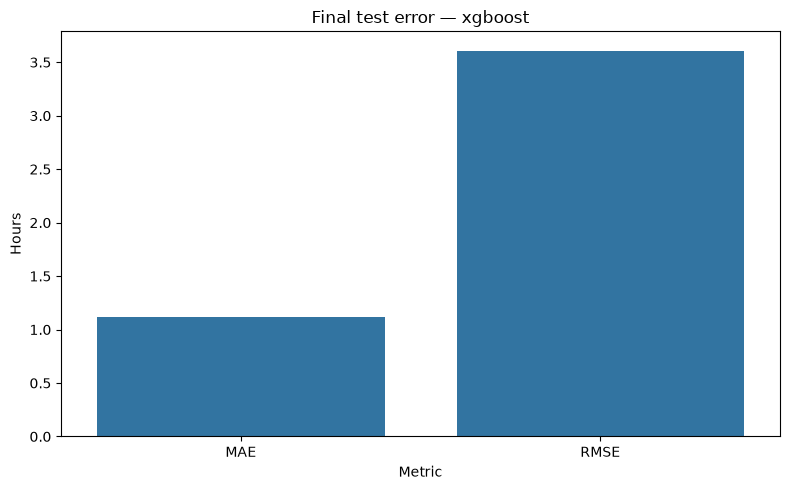

In [20]:

# ============================================================
# 19. MODEL PERFORMANCE PLOT
# ============================================================

performance_plot = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE"
    ],
    "Hours": [
        test_mae,
        test_rmse
    ]
})

plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=performance_plot,
    x="Metric",
    y="Hours"
)

plt.title(
    f"Final test error — {BEST_MODEL_NAME}"
)

plt.ylabel(
    "Hours"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "final_model_performance.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()



,original_feature,importance
13,berth_length_m,0.430708
42,month,0.211630
50,port_max_draft_m,0.061653
44,month_sin,0.058577
53,quarter,0.053828
51,port_max_dwt_mt,0.043943
52,port_max_loa_m,0.042198
34,has_special_restriction,0.028166
19,day_of_year,0.024980
49,port_max_beam_m,0.010597


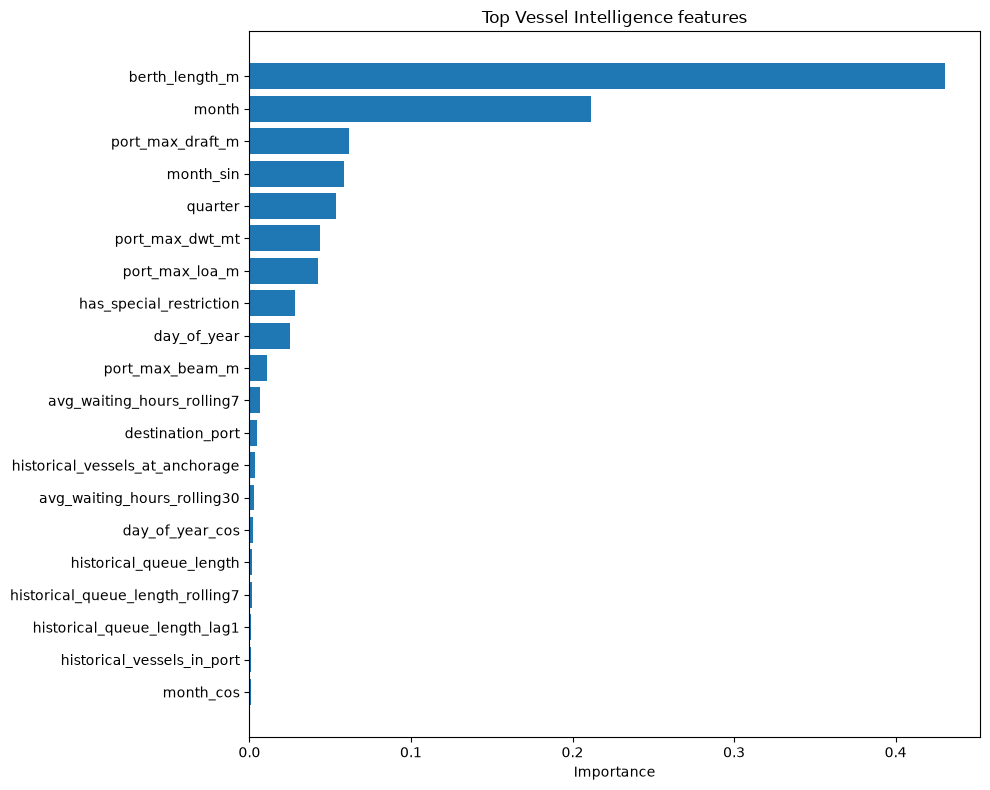

In [21]:

# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

best_preprocessor = (
    BEST_MODEL
    .named_steps["preprocess"]
)

best_estimator = (
    BEST_MODEL
    .named_steps["model"]
)

transformed_names = (
    best_preprocessor
    .get_feature_names_out()
)

if hasattr(
    best_estimator,
    "feature_importances_"
):

    raw_importance = pd.DataFrame({
        "transformed_feature":
            transformed_names,

        "importance":
            best_estimator.feature_importances_
    })

    def recover_original_feature(name):

        text = str(name)

        if "__" in text:
            text = text.split(
                "__",
                1
            )[1]

        # Find the longest matching original feature.
        matches = [
            c for c in MODEL_FEATURES
            if text == c
            or text.startswith(
                c + "_"
            )
        ]

        if not matches:
            return text

        return max(
            matches,
            key=len
        )

    raw_importance[
        "original_feature"
    ] = raw_importance[
        "transformed_feature"
    ].map(
        recover_original_feature
    )

    grouped_importance = (
        raw_importance
        .groupby(
            "original_feature",
            as_index=False
        )["importance"]
        .sum()
        .sort_values(
            "importance",
            ascending=False
        )
    )

    display(
        grouped_importance.head(25)
    )

    grouped_importance.to_csv(
        ARTIFACT_DIR /
        "feature_importance.csv",
        index=False
    )

    top_features = (
        grouped_importance
        .head(20)
        .sort_values(
            "importance"
        )
    )

    plt.figure(
        figsize=(10, 8)
    )

    plt.barh(
        top_features[
            "original_feature"
        ],
        top_features[
            "importance"
        ]
    )

    plt.title(
        "Top Vessel Intelligence features"
    )

    plt.xlabel(
        "Importance"
    )

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR /
        "feature_importance.png",
        dpi=160,
        bbox_inches="tight"
    )

    plt.show()


In [22]:

# ============================================================
# 21. SHAP EXPLANATION
# ============================================================

if (
    SHAP_AVAILABLE
    and hasattr(
        best_estimator,
        "feature_importances_"
    )
):

    try:

        shap_sample = X_test.head(
            min(
                200,
                len(X_test)
            )
        ).copy()

        encoded_sample = (
            best_preprocessor
            .transform(
                shap_sample
            )
        )

        if hasattr(
            encoded_sample,
            "toarray"
        ):
            encoded_sample = (
                encoded_sample
                .toarray()
            )

        explainer = (
            shap.TreeExplainer(
                best_estimator
            )
        )

        shap_values = (
            explainer
            .shap_values(
                encoded_sample
            )
        )

        shap_table = pd.DataFrame({

            "transformed_feature":
                transformed_names,

            "mean_abs_shap":
                np.abs(
                    shap_values
                ).mean(axis=0)
        })

        shap_table[
            "original_feature"
        ] = (
            shap_table[
                "transformed_feature"
            ]
            .map(
                recover_original_feature
            )
        )

        shap_grouped = (
            shap_table
            .groupby(
                "original_feature",
                as_index=False
            )["mean_abs_shap"]
            .sum()
            .sort_values(
                "mean_abs_shap",
                ascending=False
            )
        )

        display(
            shap_grouped.head(20)
        )

        shap_grouped.to_csv(
            ARTIFACT_DIR /
            "shap_feature_summary.csv",
            index=False
        )

    except Exception as exc:

        print(
            "SHAP skipped:",
            exc
        )

else:

    print(
        "SHAP unavailable or not supported by selected model."
    )


,original_feature,mean_abs_shap
13,berth_length_m,8.481761
42,month,8.069106
51,port_max_dwt_mt,3.865909
19,day_of_year,2.827371
10,avg_waiting_hours_rolling7,0.921830
44,month_sin,0.891451
52,port_max_loa_m,0.654535
34,has_special_restriction,0.456306
39,historical_vessels_at_anchorage,0.432635
35,historical_queue_length,0.402655


In [23]:

# ============================================================
# 22. SAFE NUMERIC HELPERS
# ============================================================

def numeric_value(
    row,
    key,
    default=np.nan
):

    if key not in row.index:
        return default

    value = pd.to_numeric(
        pd.Series(
            [row[key]]
        ),
        errors="coerce"
    ).iloc[0]

    if pd.isna(value):
        return default

    return float(value)


In [24]:

# ============================================================
# 23. PORT CONSTRAINT LOOKUP
# ============================================================

def create_port_lookup(frame):

    if "destination_port" not in frame.columns:
        raise ValueError(
            "destination_port is required."
        )

    constraint_columns = [
        "port_max_dwt_mt",
        "port_max_loa_m",
        "port_max_beam_m",
        "port_max_draft_m",
        "berth_length_m",
        "handling_rate_mt_hr",
        "berth_count",
        "has_tidal_restriction",
        "has_special_restriction",
    ]

    usable = [
        c for c in constraint_columns
        if c in frame.columns
    ]

    lookup_frame = (
        frame[
            ["date", "destination_port"]
            + usable
        ]
        .sort_values("date")
        .dropna(
            subset=["destination_port"]
        )
    )

    # Latest known row per destination.
    latest = (
        lookup_frame
        .groupby(
            "destination_port",
            as_index=False
        )
        .tail(1)
        .set_index(
            "destination_port"
        )
    )

    return latest


PORT_CONSTRAINTS = create_port_lookup(
    work
)

print(
    "\nAvailable destination constraint records:",
    len(PORT_CONSTRAINTS)
)




Available destination constraint records: 6


In [25]:

# ============================================================
# 24. HARD DESTINATION FEASIBILITY
# ============================================================

def check_destination_feasibility(
    vessel_row,
    cargo_mt,
    port_constraints
):

    failures = []

    dwt = numeric_value(
        vessel_row,
        "dwt_mt"
    )

    loa = numeric_value(
        vessel_row,
        "loa_m"
    )

    beam = numeric_value(
        vessel_row,
        "beam_m"
    )

    draft = numeric_value(
        vessel_row,
        "draft_m"
    )

    max_dwt = numeric_value(
        port_constraints,
        "port_max_dwt_mt"
    )

    max_loa = numeric_value(
        port_constraints,
        "port_max_loa_m"
    )

    max_beam = numeric_value(
        port_constraints,
        "port_max_beam_m"
    )

    max_draft = numeric_value(
        port_constraints,
        "port_max_draft_m"
    )

    berth_length = numeric_value(
        port_constraints,
        "berth_length_m"
    )

    special_restriction = numeric_value(
        port_constraints,
        "has_special_restriction",
        0
    )

    # Cargo capacity
    cargo_ok = (
        not pd.isna(dwt)
        and dwt >= cargo_mt
    )

    if not cargo_ok:
        failures.append(
            "cargo_capacity"
        )

    # DWT port limit
    if (
        not pd.isna(max_dwt)
        and not pd.isna(dwt)
        and dwt > max_dwt
    ):
        failures.append(
            "port_dwt_limit"
        )

    # LOA
    if (
        not pd.isna(max_loa)
        and not pd.isna(loa)
        and loa > max_loa
    ):
        failures.append(
            "loa"
        )

    # Beam
    if (
        not pd.isna(max_beam)
        and not pd.isna(beam)
        and beam > max_beam
    ):
        failures.append(
            "beam"
        )

    # Draft
    if (
        not pd.isna(max_draft)
        and not pd.isna(draft)
        and draft > max_draft
    ):
        failures.append(
            "draft"
        )

    # Berth length
    if (
        not pd.isna(berth_length)
        and not pd.isna(loa)
        and loa > berth_length
    ):
        failures.append(
            "berth_length"
        )

    # Special restriction
    if (
        not pd.isna(special_restriction)
        and special_restriction >= 1
    ):
        failures.append(
            "special_restriction"
        )

    return {
        "feasible":
            len(failures) == 0,

        "failure_reasons":
            "; ".join(failures),

        "cargo_capacity_ok":
            cargo_ok,

        "loa_ok":
            (
                pd.isna(max_loa)
                or pd.isna(loa)
                or loa <= max_loa
            ),

        "beam_ok":
            (
                pd.isna(max_beam)
                or pd.isna(beam)
                or beam <= max_beam
            ),

        "draft_ok":
            (
                pd.isna(max_draft)
                or pd.isna(draft)
                or draft <= max_draft
            ),
    }


In [26]:


# ============================================================
# 25. PORT COMPATIBILITY
# ============================================================

def calculate_port_compatibility(
    vessel_row,
    port_constraints
):

    checks = []

    pairs = [

        (
            "port_max_loa_m",
            "loa_m"
        ),

        (
            "port_max_beam_m",
            "beam_m"
        ),

        (
            "port_max_draft_m",
            "draft_m"
        ),

        (
            "berth_length_m",
            "loa_m"
        )
    ]

    for port_col, vessel_col in pairs:

        port_value = numeric_value(
            port_constraints,
            port_col
        )

        vessel_value = numeric_value(
            vessel_row,
            vessel_col
        )

        if (
            not pd.isna(port_value)
            and not pd.isna(vessel_value)
        ):
            checks.append(
                vessel_value <= port_value
            )

    if not checks:
        return 50.0

    return float(
        100.0 * np.mean(checks)
    )



In [27]:

# ============================================================
# 26. CARGO FIT
# ============================================================

def calculate_cargo_fit(
    cargo_mt,
    dwt_mt
):

    if (
        cargo_mt <= 0
        or dwt_mt <= 0
    ):
        return 0.0

    utilization = (
        cargo_mt /
        dwt_mt *
        100
    )

    if utilization > 100:
        return 0.0

    # Preferred operating region.
    if 70 <= utilization <= 95:

        return float(
            np.clip(
                100 -
                abs(
                    utilization - 85
                ) * 0.67,
                0,
                100
            )
        )

    if utilization < 70:

        return float(
            np.clip(
                100 -
                (
                    70 - utilization
                ) * 2,
                0,
                100
            )
        )

    return float(
        np.clip(
            100 -
            (
                utilization - 95
            ) * 4,
            0,
            100
        )
    )

In [28]:

# ============================================================
# 27. ECONOMIC SCORE
# ============================================================

if "voyage_economic_proxy" in train_df.columns:

    economic_series = pd.to_numeric(
        train_df[
            "voyage_economic_proxy"
        ],
        errors="coerce"
    )

    economic_series = (
        economic_series
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
    )

    if len(economic_series) > 0:

        ECON_LOW = float(
            economic_series.quantile(0.05)
        )

        ECON_HIGH = float(
            economic_series.quantile(0.95)
        )

    else:

        ECON_LOW = 0.0
        ECON_HIGH = 1.0

else:

    ECON_LOW = 0.0
    ECON_HIGH = 1.0


def calculate_economic_score(
    row
):

    value = numeric_value(
        row,
        "voyage_economic_proxy"
    )

    if pd.isna(value):
        return 50.0

    if ECON_HIGH <= ECON_LOW:
        return 50.0

    score = (
        100 *
        (
            value - ECON_LOW
        )
        /
        (
            ECON_HIGH - ECON_LOW
        )
    )

    return float(
        np.clip(
            score,
            0,
            100
        )
    )


In [29]:
# ============================================================
# 28. OPERATIONAL RISK SCORE
# ============================================================

WAIT_MEDIAN = float(
    train_df[TARGET].median()
)

WAIT_P90 = float(
    train_df[TARGET].quantile(0.90)
)


def calculate_operational_risk(
    row,
    predicted_wait
):

    components = []

    # Waiting risk
    if WAIT_P90 > 0:

        waiting_risk = np.clip(
            predicted_wait /
            WAIT_P90 *
            100,
            0,
            100
        )

        components.append(
            waiting_risk
        )

    # Historical queue pressure
    queue = numeric_value(
        row,
        "historical_queue_length"
    )

    if not pd.isna(queue):

        components.append(
            np.clip(
                queue /
                10 *
                100,
                0,
                100
            )
        )

    # Storm risk
    storm = numeric_value(
        row,
        "weather_storm_flag"
    )

    if not pd.isna(storm):

        components.append(
            100 if storm >= 1
            else 0
        )

    # Cyclone risk
    cyclone = numeric_value(
        row,
        "cyclone_flag"
    )

    if not pd.isna(cyclone):

        components.append(
            100 if cyclone >= 1
            else 0
        )

    # Vessel age
    age = numeric_value(
        row,
        "vessel_age_years"
    )

    if not pd.isna(age):

        components.append(
            np.clip(
                age /
                30 *
                100,
                0,
                100
            )
        )

    if not components:
        return 50.0

    return float(
        np.mean(
            components
        )
    )


In [30]:
# ============================================================
# 29. FINAL SUITABILITY SCORE
# ============================================================

def calculate_suitability_score(
    feasible,
    port_score,
    cargo_score,
    risk_score,
    economic_score
):

    # Hard rejection always wins.
    if not feasible:
        return 0.0

    score = (

        0.30 *
        np.nan_to_num(
            port_score,
            nan=50
        )

        +

        0.25 *
        np.nan_to_num(
            cargo_score,
            nan=0
        )

        +

        0.20 *
        (
            100 -
            np.nan_to_num(
                risk_score,
                nan=50
            )
        )

        +

        0.25 *
        np.nan_to_num(
            economic_score,
            nan=50
        )
    )

    return float(
        np.clip(
            score,
            0,
            100
        )
    )


In [31]:
# ============================================================
# 30. VESSEL PREDICTION / RANKING FUNCTION
# ============================================================

def predict_vessels(
    cargo,
    origin,
    destination,
    date,
    cargo_type="Coal",
    top_n=5
):

    asof = pd.Timestamp(
        date
    )

    # --------------------------------------------------------
    # Destination candidates available at prediction date.
    # --------------------------------------------------------

    candidates = work[
        (
            work["date"] <= asof
        )
        &
        (
            work[
                "destination_port"
            ]
            .astype("string")
            .str.casefold()
            ==
            str(destination).casefold()
        )
    ].copy()

    if candidates.empty:

        raise ValueError(
            f"No vessel records for "
            f"destination '{destination}' "
            f"on/before {asof.date()}."
        )

    # --------------------------------------------------------
    # Latest observation per vessel as of prediction date.
    # --------------------------------------------------------

    if "imo" in candidates.columns:

        candidates = (
            candidates
            .sort_values("date")
            .groupby(
                "imo",
                dropna=False
            )
            .tail(1)
            .copy()
        )

    else:

        candidates = (
            candidates
            .sort_values("date")
            .drop_duplicates(
                subset=["vessel_name"],
                keep="last"
            )
        )


    # --------------------------------------------------------
    # Port constraints
    # --------------------------------------------------------

    if destination not in PORT_CONSTRAINTS.index:

        raise ValueError(
            f"No destination constraints found "
            f"for '{destination}'."
        )

    port_constraints = (
        PORT_CONSTRAINTS
        .loc[destination]
    )

    ranking_rows = []


    # ========================================================
    # PROCESS EACH VESSEL
    # ========================================================

    for _, vessel in candidates.iterrows():

        dwt = numeric_value(
            vessel,
            "dwt_mt"
        )

        loa = numeric_value(
            vessel,
            "loa_m"
        )

        beam = numeric_value(
            vessel,
            "beam_m"
        )

        draft = numeric_value(
            vessel,
            "draft_m"
        )

        # ----------------------------------------------------
        # Vessel existence
        # ----------------------------------------------------

        built_year = numeric_value(
            vessel,
            "year_built"
        )

        if not pd.isna(
            built_year
        ):

            vessel_operational = (
                built_year <=
                asof.year
            )

            vessel_age = max(
                0,
                asof.year -
                built_year
            )

        else:

            flag = numeric_value(
                vessel,
                "vessel_operational_flag",
                1
            )

            vessel_operational = (
                flag >= 1
            )

            vessel_age = numeric_value(
                vessel,
                "vessel_age_years"
            )


        # ----------------------------------------------------
        # Hard feasibility
        # ----------------------------------------------------

        feasibility = (
            check_destination_feasibility(
                vessel,
                float(cargo),
                port_constraints
            )
        )

        if not vessel_operational:

            feasibility[
                "feasible"
            ] = False

            failure = (
                feasibility[
                    "failure_reasons"
                ]
            )

            feasibility[
                "failure_reasons"
            ] = (
                (
                    failure + "; "
                )
                if failure
                else ""
            ) + (
                "vessel_not_operational"
            )


        # ----------------------------------------------------
        # Dynamic scenario features
        # ----------------------------------------------------

        if (
            not pd.isna(dwt)
            and dwt > 0
        ):

            utilization = (
                100 *
                float(cargo) /
                dwt
            )

        else:

            utilization = np.nan


        cargo_score = (
            calculate_cargo_fit(
                float(cargo),
                dwt if not pd.isna(
                    dwt
                ) else 0
            )
        )


        port_score = (
            calculate_port_compatibility(
                vessel,
                port_constraints
            )
        )


        # ----------------------------------------------------
        # ML waiting-time prediction
        # ----------------------------------------------------

        ml_input = pd.DataFrame({
            feature: [
                vessel.get(
                    feature,
                    np.nan
                )
            ]
            for feature in MODEL_FEATURES
        })

        predicted_wait = float(
            np.clip(
                BEST_MODEL.predict(
                    ml_input
                )[0],
                0,
                None
            )
        )


        # ----------------------------------------------------
        # Operational risk
        # ----------------------------------------------------

        # Work on a copy so dynamic age can influence explanation
        # without changing the trained model feature schema.
        risk_row = vessel.copy()

        risk_row[
            "vessel_age_years"
        ] = vessel_age

        risk_score = (
            calculate_operational_risk(
                risk_row,
                predicted_wait
            )
        )


        # ----------------------------------------------------
        # Economic score
        # ----------------------------------------------------

        econ_score = (
            calculate_economic_score(
                vessel
            )
        )


        # ----------------------------------------------------
        # Suitability
        # ----------------------------------------------------

        suitability = (
            calculate_suitability_score(
                feasibility["feasible"],
                port_score,
                cargo_score,
                risk_score,
                econ_score
            )
        )


        # ----------------------------------------------------
        # Origin feasibility
        # ----------------------------------------------------
        # The current master dataset generally has origin
        # country, not a loading-port constraint.
        # Therefore do not falsely declare origin feasibility.
        # ----------------------------------------------------

        origin_status = "UNKNOWN"

        possible_origin_fields = [
            "origin_port",
            "loading_port",
            "loading_port_id",
            "origin_port_id",
        ]

        for field in possible_origin_fields:

            if field in vessel.index:

                value = vessel[field]

                if (
                    pd.notna(value)
                    and str(value).strip()
                ):

                    origin_status = (
                        "AVAILABLE"
                    )

                    break


        # ----------------------------------------------------
        # Margins
        # ----------------------------------------------------

        max_loa = numeric_value(
            port_constraints,
            "port_max_loa_m"
        )

        max_beam = numeric_value(
            port_constraints,
            "port_max_beam_m"
        )

        max_draft = numeric_value(
            port_constraints,
            "port_max_draft_m"
        )

        berth_length = numeric_value(
            port_constraints,
            "berth_length_m"
        )

        max_dwt = numeric_value(
            port_constraints,
            "port_max_dwt_mt"
        )


        loa_margin = (
            max_loa - loa
            if (
                not pd.isna(max_loa)
                and not pd.isna(loa)
            )
            else np.nan
        )

        beam_margin = (
            max_beam - beam
            if (
                not pd.isna(max_beam)
                and not pd.isna(beam)
            )
            else np.nan
        )

        draft_margin = (
            max_draft - draft
            if (
                not pd.isna(max_draft)
                and not pd.isna(draft)
            )
            else np.nan
        )

        dwt_margin = (
            dwt - float(cargo)
            if not pd.isna(dwt)
            else np.nan
        )

        berth_margin = (
            berth_length - loa
            if (
                not pd.isna(berth_length)
                and not pd.isna(loa)
            )
            else np.nan
        )


        # ----------------------------------------------------
        # Explanations
        # ----------------------------------------------------

        positive = []
        negative = []


        if feasibility[
            "feasible"
        ]:

            positive.append(
                "passes destination hard constraints"
            )

        else:

            negative.append(
                "rejected: "
                +
                feasibility[
                    "failure_reasons"
                ]
            )


        if (
            not pd.isna(utilization)
            and
            70 <= utilization <= 95
        ):

            positive.append(
                f"cargo utilization "
                f"{utilization:.1f}% is within "
                f"the preferred range"
            )

        elif (
            not pd.isna(utilization)
            and
            utilization < 70
        ):

            negative.append(
                f"low cargo utilization "
                f"{utilization:.1f}%"
            )

        elif (
            not pd.isna(utilization)
            and
            utilization > 95
        ):

            negative.append(
                f"high cargo utilization "
                f"{utilization:.1f}%"
            )


        if port_score >= 90:

            positive.append(
                "strong dimensional port compatibility"
            )

        elif port_score < 70:

            negative.append(
                "limited dimensional port margins"
            )


        if predicted_wait <= WAIT_MEDIAN:

            positive.append(
                f"predicted waiting "
                f"{predicted_wait:.1f}h is below "
                f"training median"
            )

        else:

            negative.append(
                f"predicted waiting "
                f"{predicted_wait:.1f}h is above "
                f"training median"
            )


        if (
            not pd.isna(vessel_age)
            and vessel_age <= 10
        ):

            positive.append(
                "relatively young vessel"
            )

        elif (
            not pd.isna(vessel_age)
            and vessel_age > 10
        ):

            negative.append(
                f"vessel age "
                f"{vessel_age:.0f} years"
            )


        if origin_status == "UNKNOWN":

            negative.append(
                "loading-port constraint "
                "not available in current dataset"
            )


        ranking_rows.append({

            "vessel_name":
                vessel.get(
                    "vessel_name",
                    ""
                ),

            "imo":
                vessel.get(
                    "imo",
                    ""
                ),

            "vessel_class":
                vessel.get(
                    "vessel_class",
                    ""
                ),

            "origin":
                origin,

            "destination":
                destination,

            "cargo_type":
                cargo_type,

            "cargo_mt":
                float(cargo),

            "as_of":
                asof.date().isoformat(),

            "feasible":
                bool(
                    feasibility[
                        "feasible"
                    ]
                ),

            "rejection_reason":
                feasibility[
                    "failure_reasons"
                ],

            "origin_constraint_status":
                origin_status,

            "destination_constraint_status":
                "AVAILABLE",

            "dwt_mt":
                dwt,

            "loa_m":
                loa,

            "beam_m":
                beam,

            "draft_m":
                draft,

            "vessel_age_years":
                vessel_age,

            "cargo_utilization_pct":
                utilization,

            "dwt_margin_mt":
                dwt_margin,

            "loa_margin_m":
                loa_margin,

            "beam_margin_m":
                beam_margin,

            "draft_margin_m":
                draft_margin,

            "berth_loa_margin_m":
                berth_margin,

            "dwt_limit_mt":
                max_dwt,

            "predicted_waiting_hours":
                predicted_wait,

            "operational_risk_score":
                risk_score,

            "economic_score":
                econ_score,

            "cargo_fit_score":
                cargo_score,

            "port_compatibility_score":
                port_score,

            "suitability_score":
                suitability,

            "positive_factors":
                " | ".join(
                    positive[:4]
                ),

            "negative_factors":
                " | ".join(
                    negative[:4]
                )
        })


    # --------------------------------------------------------
    # Rank:
    #   1. Feasible first
    #   2. Suitability descending
    #   3. Waiting ascending
    # --------------------------------------------------------

    result = pd.DataFrame(
        ranking_rows
    )

    result = (
        result
        .sort_values(
            [
                "feasible",
                "suitability_score",
                "predicted_waiting_hours"
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    result.insert(
        0,
        "rank",
        np.arange(
            1,
            len(result) + 1
        )
    )


    # Recommendation labels
    result[
        "recommendation"
    ] = np.where(

        result["feasible"]
        &
        (
            result["rank"] <= top_n
        ),

        "TOP_RECOMMENDATION",

        np.where(

            result["feasible"],

            "ELIGIBLE_ALTERNATIVE",

            "REJECT"
        )
    )

    return result


In [32]:

# ============================================================
# 31. RUN REALISTIC DEMONSTRATION
# ============================================================

example_date = work[
    "date"
].max()

recommendations = predict_vessels(

    cargo=70000,

    origin="Indonesia",

    destination="Paradip",

    date=example_date,

    cargo_type="Coal",

    top_n=5
)


In [33]:
# ============================================================
# 32. DISPLAY TOP VESSELS
# ============================================================

display_columns = [

    "rank",

    "vessel_name",

    "imo",

    "vessel_class",

    "feasible",

    "suitability_score",

    "predicted_waiting_hours",

    "operational_risk_score",

    "cargo_utilization_pct",

    "port_compatibility_score",

    "economic_score",

    "cargo_fit_score",

    "origin_constraint_status",

    "positive_factors",

    "negative_factors",
]

display(
    recommendations[
        display_columns
    ].head(10)
)


# Save recommendations
recommendations.to_csv(
    ARTIFACT_DIR /
    "final_ranked_recommendations.csv",
    index=False
)


,rank,vessel_name,imo,vessel_class,feasible,suitability_score,predicted_waiting_hours,operational_risk_score,cargo_utilization_pct,port_compatibility_score,economic_score,cargo_fit_score,origin_constraint_status,positive_factors,negative_factors
0,1,Western Pioneer,9404531,Panamax,True,68.802336,40.797939,30.036180,86.136884,100.0,0.0,99.238288,UNKNOWN,passes destination hard constraints | cargo ut...,loading-port constraint not available in curre...
1,2,Western Discovery,9264511,Panamax,True,68.679031,40.797939,31.147291,85.546336,100.0,0.0,99.633955,UNKNOWN,passes destination hard constraints | cargo ut...,loading-port constraint not available in curre...
2,3,Global Progress,9339563,Panamax,True,67.967365,41.202572,34.650415,85.612250,100.0,0.0,99.589793,UNKNOWN,passes destination hard constraints | cargo ut...,predicted waiting 41.2h is above training medi...
3,4,Star Falcon,9686782,Panamax,True,67.822401,40.797939,33.369513,88.007141,100.0,0.0,97.985215,UNKNOWN,passes destination hard constraints | cargo ut...,loading-port constraint not available in curre...
4,5,Atlantic Eagle,9638539,Panamax,True,67.512895,40.797939,30.036180,93.835038,100.0,0.0,94.080525,UNKNOWN,passes destination hard constraints | cargo ut...,loading-port constraint not available in curre...
5,6,Global Falcon,9133209,Panamax,True,67.399741,41.202572,30.205970,94.307848,100.0,0.0,93.763742,UNKNOWN,passes destination hard constraints | cargo ut...,predicted waiting 41.2h is above training medi...
6,7,Star Discovery,9874716,Panamax,True,67.167688,40.797939,32.258402,93.242577,100.0,0.0,94.477473,UNKNOWN,passes destination hard constraints | cargo ut...,loading-port constraint not available in curre...
7,8,Crown Eagle,9559190,Panamax,True,67.129908,40.797939,37.813957,86.834630,100.0,0.0,98.770798,UNKNOWN,passes destination hard constraints | cargo ut...,loading-port constraint not available in curre...
8,9,Royal Pride,9174447,Panamax,True,66.580539,40.797939,37.813957,90.114445,100.0,0.0,96.573322,UNKNOWN,passes destination hard constraints | cargo ut...,loading-port constraint not available in curre...
9,10,Silver Spirit,9184777,Panamax,True,66.313257,40.797939,36.702846,93.036856,100.0,0.0,94.615307,UNKNOWN,passes destination hard constraints | cargo ut...,loading-port constraint not available in curre...


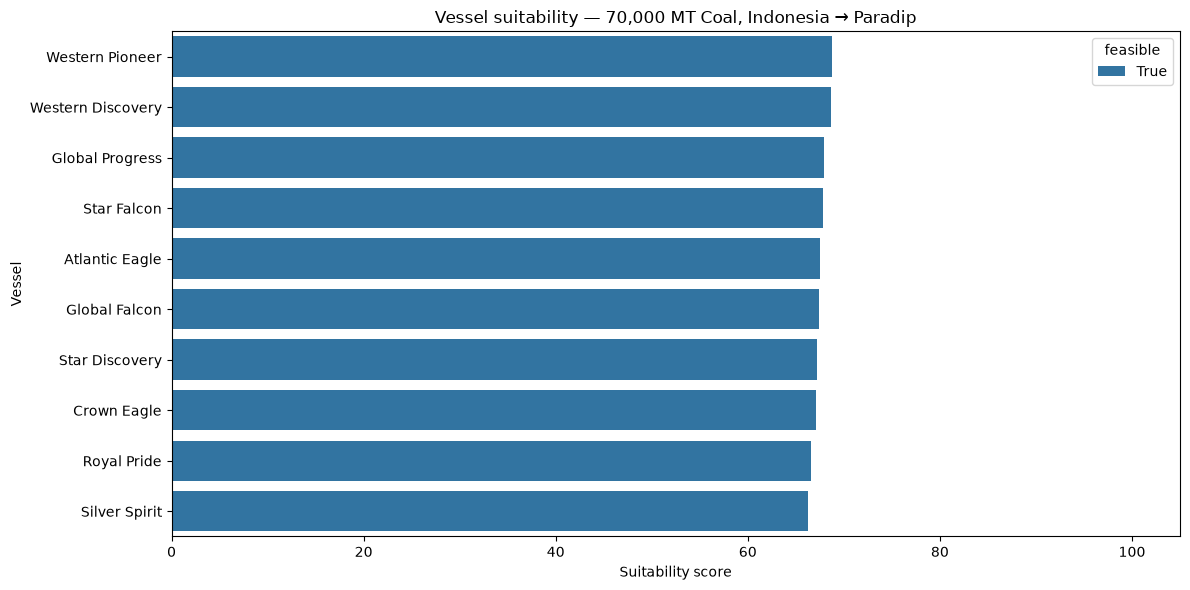

In [34]:

# ============================================================
# 33. TOP 10 VESSEL PLOT
# ============================================================

top10 = (
    recommendations
    .head(10)
    .copy()
)

plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=top10,
    x="suitability_score",
    y="vessel_name",
    hue="feasible",
    dodge=False
)

plt.xlim(
    0,
    105
)

plt.title(
    "Vessel suitability — "
    "70,000 MT Coal, Indonesia → Paradip"
)

plt.xlabel(
    "Suitability score"
)

plt.ylabel(
    "Vessel"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "top_vessel_rankings.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


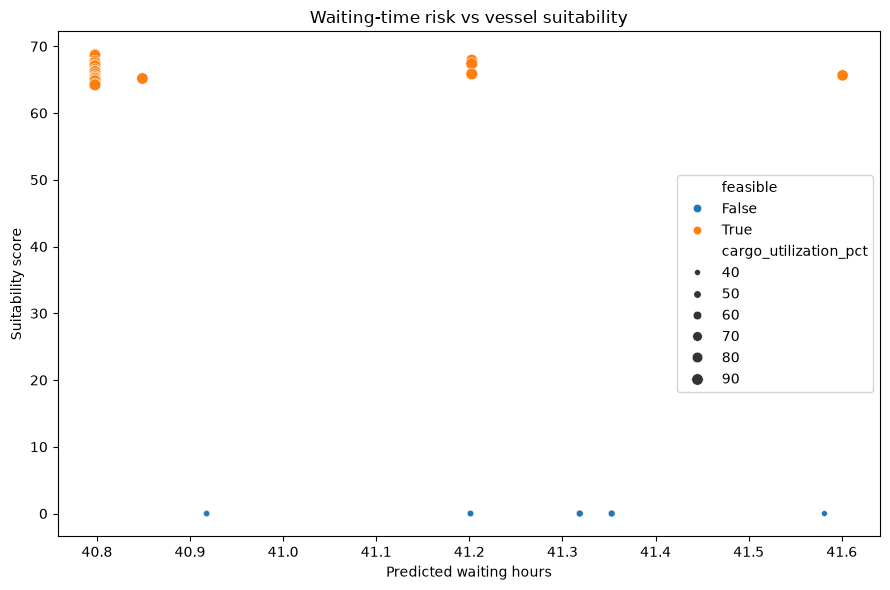

In [35]:

# ============================================================
# 34. WAITING VS SUITABILITY
# ============================================================

plt.figure(
    figsize=(9, 6)
)

sns.scatterplot(

    data=recommendations,

    x="predicted_waiting_hours",

    y="suitability_score",

    hue="feasible",

    size="cargo_utilization_pct"
)

plt.title(
    "Waiting-time risk vs vessel suitability"
)

plt.xlabel(
    "Predicted waiting hours"
)

plt.ylabel(
    "Suitability score"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "waiting_vs_suitability.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


In [36]:

# ============================================================
# 35. SAVE MODEL
# ============================================================

joblib.dump(
    BEST_MODEL,
    ARTIFACT_DIR /
    "waiting_time_model.joblib"
)

joblib.dump(
    {
        "model_features":
            MODEL_FEATURES,

        "numeric_features":
            numeric_columns,

        "categorical_features":
            categorical_columns,

        "target":
            TARGET,

        "train_end":
            str(
                TRAIN_END.date()
            ),

        "validation_end":
            str(
                VALIDATION_END.date()
            ),
    },
    ARTIFACT_DIR /
    "preprocessing_artifacts.joblib"
)


['c:\\Users\\samag\\OneDrive\\Desktop\\Hackathon\\SIH2026\\LSTM_model\\vessel_intelligence\\vessel_intelligence_artifacts\\preprocessing_artifacts.joblib']

In [37]:

# ============================================================
# 36. SAVE METADATA
# ============================================================

metadata = {

    "model_name":
        "Vessel Intelligence Waiting-Time Model",

    "model_version":
        "2.0.0",

    "selected_model":
        BEST_MODEL_NAME,

    "target":
        TARGET,

    "objective":
        "Predict operational waiting time for vessel screening and ranking",

    "data_path":
        str(
            DATA_PATH.resolve()
        ),

    "data_start":
        str(
            work["date"]
            .min()
            .date()
        ),

    "data_end":
        str(
            work["date"]
            .max()
            .date()
        ),

    "train_end":
        str(
            TRAIN_END.date()
        ),

    "validation_end":
        str(
            VALIDATION_END.date()
        ),

    "test_start":
        str(
            test_df["date"]
            .min()
            .date()
        ),

    "feature_count":
        len(MODEL_FEATURES),

    "features":
        MODEL_FEATURES,

    "test_metrics":
        {
            "MAE_hours":
                float(test_mae),

            "RMSE_hours":
                float(test_rmse),

            "R2":
                float(test_r2)
        },

    "xgboost_available":
        XGB_AVAILABLE,

    "shap_available":
        SHAP_AVAILABLE,

    "origin_constraint_policy":
        "UNKNOWN when a specific loading-port constraint is unavailable",

    "ranking_policy":
        "Hard-ineligible vessels always rank below feasible vessels",

    "prototype_label_policy":
        "Suitability and eligibility fields are not used as supervised ground truth",

    "synthetic_data_warning":
        "Synthetic/proxy market fields must not be represented as official market observations."
}


(
    ARTIFACT_DIR /
    "metadata.json"
).write_text(
    json.dumps(
        metadata,
        indent=2
    ),
    encoding="utf-8"
)



2956

In [38]:

# ============================================================
# 37. FINAL SELECTED VESSEL
# ============================================================

if not recommendations.empty:

    selected = recommendations.iloc[0]

    print("\n" + "=" * 80)
    print("FINAL VESSEL INTELLIGENCE RESULT")
    print("=" * 80)

    print(
        "Selected vessel:",
        selected["vessel_name"]
    )

    print(
        "Vessel class:",
        selected["vessel_class"]
    )

    print(
        "Feasible:",
        selected["feasible"]
    )

    print(
        "Suitability score:",
        round(
            selected[
                "suitability_score"
            ],
            2
        )
    )

    print(
        "Predicted waiting:",
        round(
            selected[
                "predicted_waiting_hours"
            ],
            2
        ),
        "hours"
    )

    print(
        "Operational risk:",
        round(
            selected[
                "operational_risk_score"
            ],
            2
        )
    )

    print(
        "Economic score:",
        round(
            selected[
                "economic_score"
            ],
            2
        )
    )

    print(
        "Cargo fit:",
        round(
            selected[
                "cargo_fit_score"
            ],
            2
        )
    )

    print(
        "Port compatibility:",
        round(
            selected[
                "port_compatibility_score"
            ],
            2
        )
    )

    print(
        "\nPositive factors:",
        selected[
            "positive_factors"
        ]
    )

    print(
        "Negative factors:",
        selected[
            "negative_factors"
        ]
    )



FINAL VESSEL INTELLIGENCE RESULT
Selected vessel: Western Pioneer
Vessel class: Panamax
Feasible: True
Suitability score: 68.8
Predicted waiting: 40.8 hours
Operational risk: 30.04
Economic score: 0.0
Cargo fit: 99.24
Port compatibility: 100.0

Positive factors: passes destination hard constraints | cargo utilization 86.1% is within the preferred range | strong dimensional port compatibility | predicted waiting 40.8h is below training median
Negative factors: loading-port constraint not available in current dataset


In [39]:

# ============================================================
# 38. ARTIFACT SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("ARTIFACTS CREATED")
print("=" * 80)

artifact_files = sorted(
    ARTIFACT_DIR.rglob("*")
)

for file in artifact_files:

    if file.is_file():
        print(
            " -",
            file.relative_to(
                ARTIFACT_DIR
            )
        )

print("\nVessel Intelligence notebook pipeline completed.")


ARTIFACTS CREATED
 - data_quality_profile.csv
 - feature_importance.csv
 - final_ranked_recommendations.csv
 - final_test_metrics.csv
 - metadata.json
 - plots\feature_importance.png
 - plots\final_model_performance.png
 - plots\top_vessel_rankings.png
 - plots\waiting_vs_suitability.png
 - preprocessing_artifacts.joblib
 - shap_feature_summary.csv
 - test_prediction_diagnostics.csv
 - validation_results.csv
 - waiting_time_model.joblib

Vessel Intelligence notebook pipeline completed.
